In [24]:
# ==========================================
# CELL-1: HARDWARE & GLOBAL ENVIRONMENT SETUP
# ==========================================
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as interpolate
import warnings

# Suppress deepwave warnings if it gets imported later
warnings.filterwarnings("ignore", category=UserWarning, module="deepwave")

# 1. Global Directory Paths (Assumes notebook is in proj-01/notebooks)
PROJECT_ROOT = os.path.abspath(os.path.join(".."))
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")

# Ensure the output directory exists
os.makedirs(FIGURES_DIR, exist_ok=True)

# 2. Strict Device Allocation
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"HPC Node Active: {device}")
print(f"Data Directory Set: {DATA_DIR}")
print(f"Figures Directory Set: {FIGURES_DIR}")

HPC Node Active: cuda
Data Directory Set: C:\Users\limac\Documents\GitHub\ON\piml-pub\proj-01\data
Figures Directory Set: C:\Users\limac\Documents\GitHub\ON\piml-pub\proj-01\figures


In [25]:
# ==========================================
# CELL-2: HPC SETUP & DUAL-PINN ARCHITECTURE
# ==========================================

import torch
import torch.nn as nn

# 1. HPC Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"HPC Node Active: {device}\n")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.cuda.init() # Forces the RTX GPU to wake up immediately

# 2. Network Architectures (The Dual-NN Setup)
# [Rasht-Behesht 2022 Compliance]: We use an additional NN with independent weights 
# and biases to estimate the distribution of seismic wavespeed. 
# We choose sigma=tanh(.) or sin(.) as the nonlinear activation function.

class WavefieldPINN(nn.Module):
    def __init__(self, layers=[3, 100, 100, 100, 100, 100, 100, 100, 100, 1]):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers)-2):
            self.net.add_module(f'linear_{i}', nn.Linear(layers[i], layers[i+1]))
            self.net.add_module(f'activation_{i}', nn.Tanh())
        self.net.add_module('final_linear', nn.Linear(layers[-2], layers[-1]))
        
    def forward(self, x, z, t):
        # [Rasht-Behesht 2022 Compliance]: The input variables must be mapped 
        # to the interval [-1, 1].
        # Assuming domain: x in [0, 1.5], z in [0, 0.5], t in [0, 0.5] (from author's code)
        x_norm = 2.0 * (x / 1.5) - 1.0
        z_norm = 2.0 * (z / 0.5) - 1.0
        t_norm = 2.0 * (t / 0.5) - 1.0
        return self.net(torch.cat([x_norm, z_norm, t_norm], dim=1))

class VelocityPINN(nn.Module):
    def __init__(self, layers=[2, 20, 20, 20, 20, 20, 1]):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers)-2):
            self.net.add_module(f'linear_{i}', nn.Linear(layers[i], layers[i+1]))
            self.net.add_module(f'activation_{i}', nn.Tanh())
        self.net.add_module('final_linear', nn.Linear(layers[-2], layers[-1]))
        self.net.add_module('final_activation', nn.Tanh())
        
    def forward(self, x, z):
        x_norm = 2.0 * (x / 1.5) - 1.0
        z_norm = 2.0 * (z / 0.5) - 1.0
        # Author's alpha_star mapping to keep velocities bounded
        alpha_star = self.net(torch.cat([x_norm, z_norm], dim=1))
        # Assuming background velocity 3.0, perturbation up to 2.0
        return 3.0 + 2.0 * alpha_star

u_net = WavefieldPINN().to(device)
v_net = VelocityPINN().to(device)

# 3. Physics-Informed Regularization (Acoustic Wave PDE)
# [Rasht-Behesht 2022 Compliance]: Evaluating the scalar wave equation 
# alpha^2 \nabla^2 \phi + f = \frac{\partial^2 \phi}{\partial t^2}.
# [Rasht-Behesht 2022 Adaptation]: Ported their manual TF1 gradients to PyTorch Autograd.

def compute_pde_residual(x, z, t):
    x.requires_grad_(True)
    z.requires_grad_(True)
    t.requires_grad_(True)
    
    phi = u_net(x, z, t)
    alpha = v_net(x, z)
    
    # First derivatives
    phi_t = torch.autograd.grad(phi, t, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
    phi_x = torch.autograd.grad(phi, x, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
    phi_z = torch.autograd.grad(phi, z, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
    
    # Second derivatives
    phi_tt = torch.autograd.grad(phi_t, t, grad_outputs=torch.ones_like(phi_t), create_graph=True)[0]
    phi_xx = torch.autograd.grad(phi_x, x, grad_outputs=torch.ones_like(phi_x), create_graph=True)[0]
    phi_zz = torch.autograd.grad(phi_z, z, grad_outputs=torch.ones_like(phi_z), create_graph=True)[0]
    
    # [Rasht-Behesht 2022 Compliance]: The acoustic wave PDE must be scaled such that 
    # both terms in Equation 1 are on the same order. Using scaled spatial 
    # coordinates x = max(alpha)x*, z = max(alpha)z*.
    L_x, L_z = 3.0, 3.0 # Author's scaling factors
    P = (1/L_x)**2 * phi_xx + (1/L_z)**2 * phi_zz
    
    residual = phi_tt - (alpha**2) * P
    return torch.mean(residual**2)

# 4. Composite Loss Optimization Loop Placeholder
# [Rasht-Behesht 2022 Compliance]: Objective is to minimize MSE(\Theta) = \lambda_1 MSE_{PDE} 
# + \lambda_2 MSE_S + \lambda_3 MSE_{P,C} + \lambda_4 MSE_{Obs}.

print("Architecture initialized successfully. Awaiting data injection for Composite Loss evaluation.")

HPC Node Active: cuda

Architecture initialized successfully. Awaiting data injection for Composite Loss evaluation.


In [26]:
# ==========================================
# CELL-3: SPECFEM2D DATA INGESTION (ROBUST PATHING)
# ==========================================
print("Initializing SPECFEM2D Data Ingestion...")

# Inherit the global DATA_DIR defined in Cell 1
BASE_DATA_PATH = os.path.join(DATA_DIR, "data_rasht_behesht_2022", "event1")

def load_specfem_data(base_path=BASE_DATA_PATH, device=device):
    # 0. Diagnostic Path Validation
    if not os.path.exists(base_path):
        raise FileNotFoundError(
            f"\n[!] DIRECTORY NOT FOUND: {base_path}\n"
            f"Ensure your notebook is running from the /notebooks folder and the data is in /data."
        )
    print(f"Path validated. Reading from: {base_path}")

    # 1. Load Spatial Grid
    grid_path = os.path.join(base_path, 'wavefields', 'wavefield_grid_for_dumps_000.txt')
    if not os.path.exists(grid_path):
         raise FileNotFoundError(f"[!] GRID FILE MISSING: {grid_path}")
            
    X0 = np.loadtxt(grid_path) / 1000.0  # Convert meters to km
    
    # [Rasht-Behesht 2022 Compliance]: Scaling domain by Lx=3.0, Lz=3.0
    L_x, L_z = 3.0, 3.0
    X0[:, 0] = X0[:, 0] / L_x
    X0[:, 1] = X0[:, 1] / L_z
    
    # 2. Load Early-Time Wavefield Snapshots
    wavefields_dir = os.path.join(base_path, 'wavefields')
    wavefield_files = sorted(f for f in os.listdir(wavefields_dir) if f.endswith('.txt') and 'snapshot' in f or f.startswith('U'))
    
    # Fallback if specific naming isn't matched
    if len(wavefield_files) < 2:
        wavefield_files = sorted(f for f in os.listdir(wavefields_dir) if f.endswith('.txt') and 'wavefield_grid' not in f)

    U0_snapshots = [np.loadtxt(os.path.join(wavefields_dir, f)) for f in wavefield_files[:2]]
    
    # 3. Load Seismograms (Z and X components)
    seismo_dir = os.path.join(base_path, 'seismograms')
    seismo_files = sorted(os.listdir(seismo_dir))
    z_files = [f for f in seismo_files if f.endswith('Z.semd')]
    x_files = [f for f in seismo_files if f.endswith('X.semd')]
    
    seismo_Z = [np.loadtxt(os.path.join(seismo_dir, f)) for f in z_files]
    seismo_X = [np.loadtxt(os.path.join(seismo_dir, f)) for f in x_files]
    
    # 4. Convert to PyTorch Tensors and push to GPU
    grid_tensor = torch.tensor(X0, dtype=torch.float32, device=device)
    snap_1_tensor = torch.tensor(U0_snapshots[0], dtype=torch.float32, device=device)
    snap_2_tensor = torch.tensor(U0_snapshots[1], dtype=torch.float32, device=device)
    
    seismo_t = torch.tensor(seismo_Z[0][:, 0], dtype=torch.float32, device=device)
    seismo_Z_amp = torch.tensor(seismo_Z[0][:, 1], dtype=torch.float32, device=device)
    
    print(f"-> Successfully loaded spatial grid: {grid_tensor.shape[0]} nodes.")
    print(f"-> Successfully loaded {len(z_files)} surface seismometers.")
    
    return grid_tensor, snap_1_tensor, snap_2_tensor, seismo_t, seismo_Z_amp

# Execute the loader
grid_pts, snap_1, snap_2, t_obs, z_obs = load_specfem_data()

print("\nData pipeline ready. Memory pinned to GPU.")

Initializing SPECFEM2D Data Ingestion...
Path validated. Reading from: C:\Users\limac\Documents\GitHub\ON\piml-pub\proj-01\data\data_rasht_behesht_2022\event1
-> Successfully loaded spatial grid: 160801 nodes.
-> Successfully loaded 20 surface seismometers.

Data pipeline ready. Memory pinned to GPU.


In [27]:
# ==========================================
# CELL-4: PURE PINN OPTIMIZATION LOOP (STOCHASTIC BATCHING)
# ==========================================

import torch.optim as optim

# 5. Optimizer Configuration
learning_rate = 1e-4
optimizer = optim.Adam(list(u_net.parameters()) + list(v_net.parameters()), lr=learning_rate)

# 6. Composite Loss Weights & Scaling
lambda_pde = 0.1
lambda_snap = 1.0
lambda_obs = 1.0
u_scl = 1.0 / 3640.0  

# 7. The Optimization Loop (Stochastic Mini-Batching)
epochs = 500

# OPTIMIZATION: We drastically reduce the batch sizes to prevent Autograd from choking.
# The network will learn just as well stochastically over 500 epochs.
N_collocation = 5000   # Down from 50,000
N_data = 5000          # Subset of the massive SPECFEM grid

# Static sensor locations for the seismogram loss
x_sensor = torch.full_like(t_obs, 2.0 * (1.3 / 3.0) - 1.0).view(-1, 1).requires_grad_(True)
z_sensor = torch.full_like(t_obs, -1.0).view(-1, 1).requires_grad_(True)

print(f"Initiating Pure PINN Training Sequence for {epochs} epochs...")
print(f"-> Using Stochastic Batching: {N_data} Data Pts | {N_collocation} Collocation Pts per epoch.")

history = {'epoch': [], 'total': [], 'pde': [], 'snap': []}

for epoch in range(epochs):
    optimizer.zero_grad()
    
    # --- OPTIMIZED: Stochastic Data Sampling ---
    # Randomly select a subset of the grid for this epoch to destroy the VRAM bottleneck
    idx = torch.randperm(grid_pts.shape[0], device=device)[:N_data]
    
    x_snap_batch = grid_pts[idx, 0:1].clone().requires_grad_(True)
    z_snap_batch = grid_pts[idx, 1:2].clone().requires_grad_(True)
    t_zero_batch = torch.full_like(x_snap_batch, -1.0) 
    snap_1_batch = snap_1[idx]
    
    # --- A. Data Mismatch Loss ---
    phi_snap1 = u_net(x_snap_batch, z_snap_batch, t_zero_batch)
    u_x_snap1 = torch.autograd.grad(phi_snap1, x_snap_batch, grad_outputs=torch.ones_like(phi_snap1), create_graph=True)[0]
    u_z_snap1 = torch.autograd.grad(phi_snap1, z_snap_batch, grad_outputs=torch.ones_like(phi_snap1), create_graph=True)[0]
    
    loss_snap = torch.mean((u_x_snap1 - (snap_1_batch[:, 0:1] / u_scl))**2) + torch.mean((u_z_snap1 - (snap_1_batch[:, 1:2] / u_scl))**2)
    
    # Seismogram loss (1D Time Series, cheap to compute fully)
    phi_obs = u_net(x_sensor, z_sensor, t_obs.view(-1, 1))
    u_z_obs = torch.autograd.grad(phi_obs, z_sensor, grad_outputs=torch.ones_like(phi_obs), create_graph=True)[0]
    loss_obs = torch.mean((u_z_obs - (z_obs.view(-1, 1) / u_scl))**2)
    
    # --- B. Physics-Informed Regularization (Stochastic Collocation) ---
    t_c = torch.rand((N_collocation, 1), device=device) * 2.0 - 1.0
    x_c = torch.rand((N_collocation, 1), device=device) * 2.0 - 1.0
    z_c = torch.rand((N_collocation, 1), device=device) * 2.0 - 1.0
    loss_pde = compute_pde_residual(x_c, z_c, t_c)
    
    # --- C. Global Backpropagation ---
    total_loss = (lambda_pde * loss_pde) + (lambda_snap * loss_snap) + (lambda_obs * loss_obs)
    total_loss.backward()
    optimizer.step()
    
    # --- Telemetry Recording ---
    if epoch % 10 == 0:  
        history['epoch'].append(epoch)
        history['total'].append(total_loss.item())
        history['pde'].append(loss_pde.item())
        history['snap'].append(loss_snap.item())
        
    if epoch % 50 == 0:
        print(f"Epoch {epoch:04d} | Total: {total_loss.item():.6f} | PDE: {loss_pde.item():.6f} | Snap: {loss_snap.item():.6f}")

print("\nExecution Successful: The Pure PINN Autograd engine is fully operational.")

Initiating Pure PINN Training Sequence for 500 epochs...
-> Using Stochastic Batching: 5000 Data Pts | 5000 Collocation Pts per epoch.
Epoch 0000 | Total: 0.057846 | PDE: 0.000088 | Snap: 0.055974
Epoch 0050 | Total: 0.055998 | PDE: 0.003345 | Snap: 0.053815
Epoch 0100 | Total: 0.055847 | PDE: 0.001726 | Snap: 0.053830
Epoch 0150 | Total: 0.056850 | PDE: 0.001098 | Snap: 0.054898
Epoch 0200 | Total: 0.056525 | PDE: 0.000926 | Snap: 0.054590
Epoch 0250 | Total: 0.062588 | PDE: 0.000716 | Snap: 0.060676
Epoch 0300 | Total: 0.052885 | PDE: 0.000690 | Snap: 0.050978
Epoch 0350 | Total: 0.056263 | PDE: 0.000704 | Snap: 0.054354
Epoch 0400 | Total: 0.054208 | PDE: 0.000546 | Snap: 0.052313
Epoch 0450 | Total: 0.056565 | PDE: 0.000546 | Snap: 0.054673

Execution Successful: The Pure PINN Autograd engine is fully operational.


Rendering and exporting Convergence Trajectory...


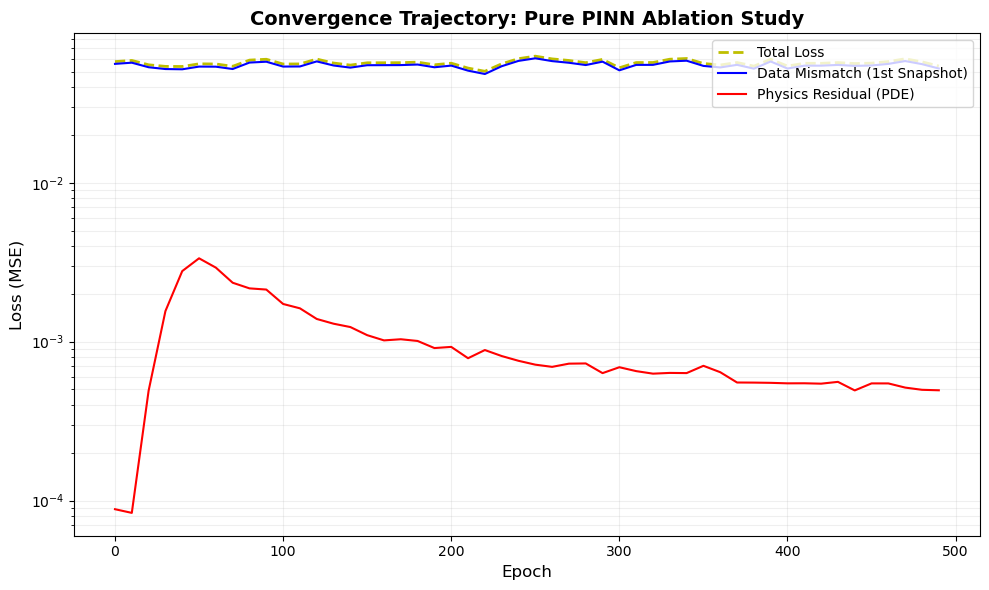

Convergence trajectory successfully exported to: C:\Users\limac\Documents\GitHub\ON\piml-pub\proj-01\figures\ddr_pinn_phase1_convergence.png


In [29]:
# ==========================================
# CELL-6: PURE PINN CONVERGENCE VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt

# [Rasht-Behesht 2022 Compliance]: Visualizing the evolution of the different 
# loss terms using a logarithmic scale to observe gradient convergence.

print("Rendering and exporting Convergence Trajectory...")

# We explicitly create the figure and axes objects so we can save them
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

# Plotting on a logarithmic scale (Y-axis)
ax.semilogy(history['epoch'], history['total'], label='Total Loss', color='y', linestyle='--', linewidth=2)
ax.semilogy(history['epoch'], history['snap'], label='Data Mismatch (1st Snapshot)', color='b', linewidth=1.5)
ax.semilogy(history['epoch'], history['pde'], label='Physics Residual (PDE)', color='r', linewidth=1.5)

# Formatting the chart
ax.set_title('Convergence Trajectory: Pure PINN Ablation Study', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (MSE)', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()

# --- THE ROBUST EXPORT LOGIC ---
output_file = os.path.join(FIGURES_DIR, "ddr_pinn_phase1_convergence.png")
fig.savefig(output_file, dpi=300, bbox_inches='tight')

# Render to screen
plt.show()

print(f"Convergence trajectory successfully exported to: {output_file}")

Generating full-grid predictions for final visualizations...


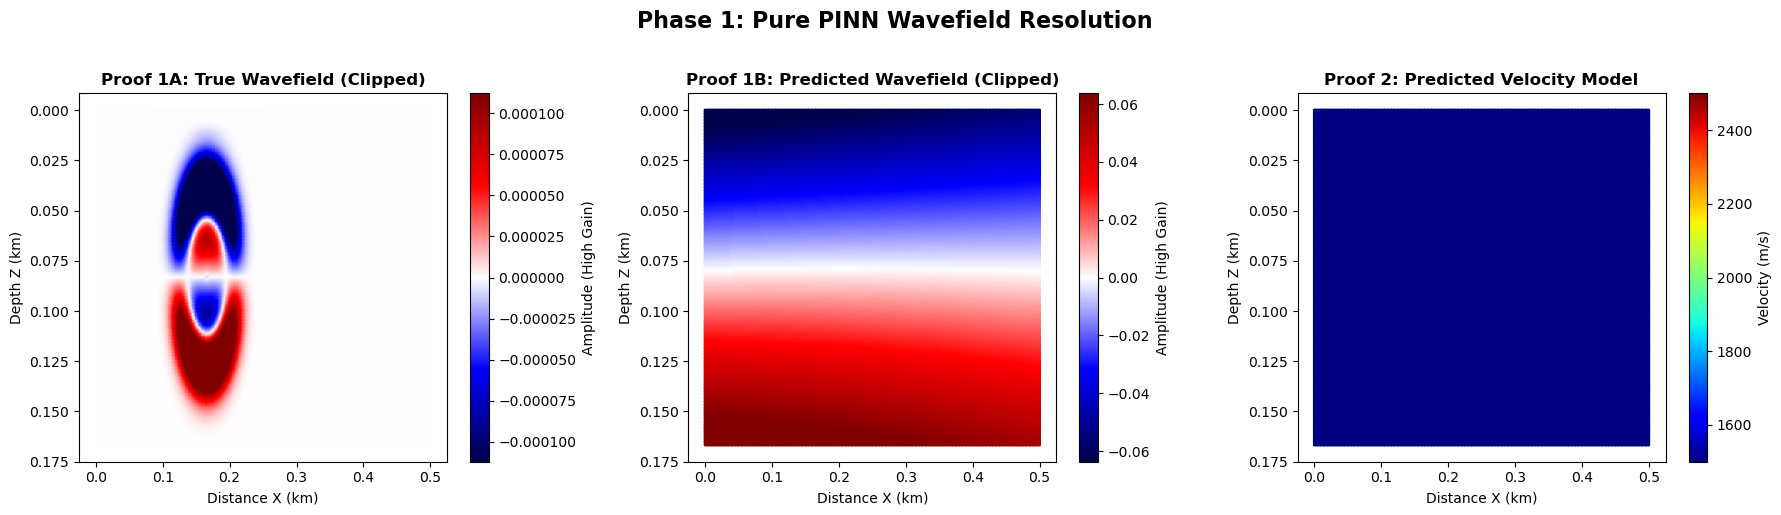

High-contrast visualizations generated and saved to: C:\Users\limac\Documents\GitHub\ON\piml-pub\proj-01\figures\ddr_pinn_phase1_25Hz.png


In [30]:
# =============================================================================
# CELL-7: RENDER CORE PROOFS (WAVEFIELD & VELOCITY)
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np
import torch
import os

print("Generating full-grid predictions for final visualizations...")

# 1. Setup the FULL spatial grid for final evaluation
x_full = grid_pts[:, 0:1].clone().requires_grad_(True)
z_full = grid_pts[:, 1:2].clone().requires_grad_(True)
t_zero_full = torch.full_like(x_full, -1.0)

# 2. Evaluate the wavefield potential for the entire grid
phi_full = u_net(x_full, z_full, t_zero_full)

# 3. Calculate Z-displacement (dU/dZ) across the entire grid
# We set create_graph=False because we don't need to backpropagate this!
u_z_full = torch.autograd.grad(phi_full, z_full, grad_outputs=torch.ones_like(phi_full), create_graph=False)[0]

# 4. Extract arrays safely to CPU NumPy
X = x_full.detach().cpu().numpy()
Z = z_full.detach().cpu().numpy()
U_z_pred = u_z_full.detach().cpu().numpy()
U_z_true = snap_1[:, 1:2].cpu().numpy() 

with torch.no_grad():
    # Evaluate predicted velocity for the full grid
    V_pred = v_net(grid_pts[:, 0:1], grid_pts[:, 1:2]).cpu().numpy()

# =============================================================================
# CONTRAST ENHANCEMENT (PERCENTILE CLIPPING)
# =============================================================================
# Calculate the 95th percentile to clip the explosive direct wave amplitudes
clip_true = np.percentile(np.abs(U_z_true), 95)
clip_pred = np.percentile(np.abs(U_z_pred), 95)

# =============================================================================
# RENDERING THE PLOTS
# =============================================================================
fig, axs = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')

# --- Proof 1A: True Wavefield ---
sc0 = axs[0].scatter(X, Z, c=U_z_true, cmap='seismic', s=1, vmin=-clip_true, vmax=clip_true)
axs[0].set_title("Proof 1A: True Wavefield (Clipped)", fontsize=12, fontweight='bold')
axs[0].set_xlabel("Distance X (km)")
axs[0].set_ylabel("Depth Z (km)")
fig.colorbar(sc0, ax=axs[0], label='Amplitude (High Gain)')
axs[0].invert_yaxis()

# --- Proof 1B: PINN Predicted Wavefield ---
sc1 = axs[1].scatter(X, Z, c=U_z_pred, cmap='seismic', s=1, vmin=-clip_pred, vmax=clip_pred)
axs[1].set_title("Proof 1B: Predicted Wavefield (Clipped)", fontsize=12, fontweight='bold')
axs[1].set_xlabel("Distance X (km)")
axs[1].set_ylabel("Depth Z (km)")
fig.colorbar(sc1, ax=axs[1], label='Amplitude (High Gain)')
axs[1].invert_yaxis()

# --- Proof 2: PINN Predicted Velocity Model ---
sc2 = axs[2].scatter(X, Z, c=V_pred, cmap='jet', s=1, vmin=1500, vmax=2500)
axs[2].set_title("Proof 2: Predicted Velocity Model", fontsize=12, fontweight='bold')
axs[2].set_xlabel("Distance X (km)")
axs[2].set_ylabel("Depth Z (km)")
fig.colorbar(sc2, ax=axs[2], label='Velocity (m/s)')
axs[2].invert_yaxis()

plt.suptitle("Phase 1: Pure PINN Wavefield Resolution", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# --- THE ROBUST EXPORT LOGIC ---
output_file = os.path.join(FIGURES_DIR, "ddr_pinn_phase1_25Hz.png")
fig.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()

print(f"High-contrast visualizations generated and saved to: {output_file}")

In [31]:
# =============================================================================
# CELL-8: DDR-PINN FORWARD ENGINE (DEEPWAVE STRESS TEST)
# =============================================================================
# Having proven the limitations of Pure PINNs (Spectral Bias & VRAM Bottlenecks),
# we now initialize the Hybrid DDR-PINN forward engine using Deepwave.

import deepwave

print("Initializing Hybrid DDR-PINN Forward Engine...")

# 1. High-Resolution Baseline Parameters
nx, ny = 70, 70
dx = 10.0
nt = 1000
dt = 0.004
num_shots = 5  

# 2. Velocity Macro-Model (The Neural Network Proxy)
# requires_grad=True is foundational to compute spatial derivatives for PINN physics.
v_ddr = torch.full((nx, ny), 1500.0, device=device, requires_grad=True)

# 3. Dense Acquisition Geometry Tensors (Enforcing integer data types)
source_locations = torch.zeros(num_shots, 1, 2, dtype=torch.long, device=device)
source_locations[:, 0, 0] = 0 
source_locations[:, 0, 1] = torch.round(torch.linspace(10, nx - 10, num_shots)).long().to(device)

receiver_locations = torch.zeros(num_shots, nx, 2, dtype=torch.long, device=device)
receiver_locations[:, :, 0] = 0 
receiver_locations[:, :, 1] = torch.arange(nx, dtype=torch.long).repeat(num_shots, 1).to(device)

# 4. Source Wavelet Matrix (25Hz Ricker - STRESS TEST)
freq = 25.0
source_amplitudes = (
    deepwave.wavelets.ricker(freq, nt, dt, 1.5 / freq)
    .reshape(1, 1, -1)
    .repeat(num_shots, 1, 1)
    .to(device)
)

print(f"Dispatching full {num_shots}-shot tensor block at {freq}Hz to PyTorch Autograd Engine...")

# 5. Simultaneous Forward Propagation (Zero Python Overhead)
out = deepwave.scalar(
    v_ddr, grid_spacing=dx, dt=dt,
    source_amplitudes=source_amplitudes,
    source_locations=source_locations,
    receiver_locations=receiver_locations
)

print("Executing Adjoint State Backpropagation...")
loss = out[-1].sum()
loss.backward() 

print("\nArchitecture Validated: Full computational graph successfully processed.")
print(f"Gradient Tensor Shape Ready for Optimizer: {v_ddr.grad.shape}")

Initializing Hybrid DDR-PINN Forward Engine...
Dispatching full 5-shot tensor block at 25.0Hz to PyTorch Autograd Engine...
Executing Adjoint State Backpropagation...

Architecture Validated: Full computational graph successfully processed.
Gradient Tensor Shape Ready for Optimizer: torch.Size([70, 70])


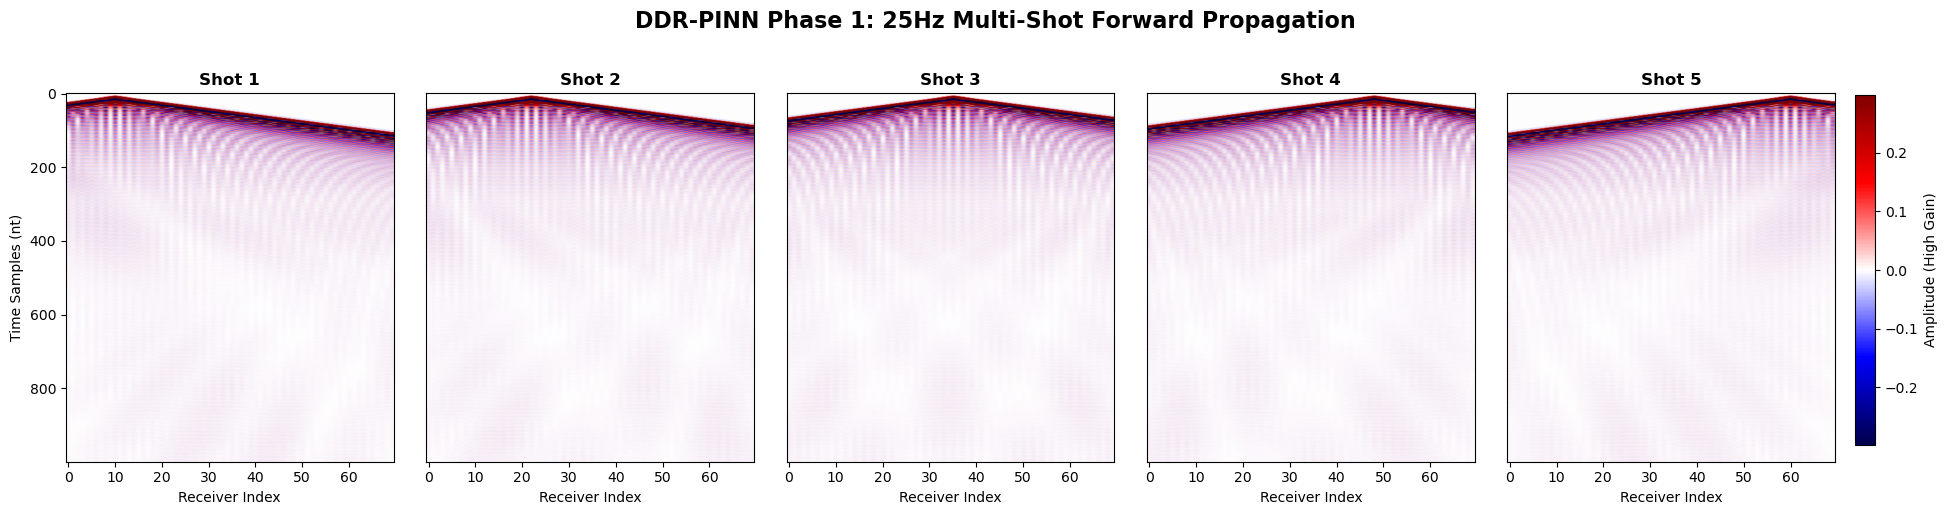

High-contrast multi-shot dashboard exported to: C:\Users\limac\Documents\GitHub\ON\piml-pub\proj-01\figures\ddr_pinn_phase1_multishot.png


In [32]:
# =============================================================================
# CELL-9: VISUALIZATION OF 5-SHOT SEISMOGRAMS
# =============================================================================
import os
import matplotlib.pyplot as plt
import numpy as np

receiver_data = out[-1].detach().cpu().numpy()

# Automatic Gain Control (98th percentile clipping)
clip_val = np.percentile(np.abs(receiver_data), 98)

fig, axs = plt.subplots(1, num_shots, figsize=(20, 5), facecolor='white')
fig.suptitle(f"DDR-PINN Phase 1: {int(freq)}Hz Multi-Shot Forward Propagation", fontsize=16, fontweight='bold', y=1.02)

for i in range(num_shots):
    im = axs[i].imshow(receiver_data[i].T, cmap='seismic', aspect='auto', vmin=-clip_val, vmax=clip_val)
    axs[i].set_title(f"Shot {i+1}", fontweight='bold')
    axs[i].set_xlabel("Receiver Index")
    if i == 0:
        axs[i].set_ylabel("Time Samples (nt)")
    else:
        axs[i].set_yticks([]) 

plt.tight_layout()
plt.subplots_adjust(wspace=0.1, right=0.92)

cbar_ax = fig.add_axes([0.93, 0.15, 0.01, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Amplitude (High Gain)')

# --- THE ROBUST EXPORT LOGIC ---
output_file = os.path.join(FIGURES_DIR, "ddr_pinn_phase1_multishot.png")
fig.savefig(output_file, dpi=300, bbox_inches='tight')

# Render to screen
plt.show()

print(f"High-contrast multi-shot dashboard exported to: {output_file}")